In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [2]:
# Standard library imports
import random
import warnings
from pathlib import Path

# Data handling and visualization imports
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Deep learning framework imports - PyTorch and Keras
import torch
from torch.utils.data import Dataset, DataLoader
import keras
from keras import layers
from keras.applications import MobileNetV2

# Cats vs dogs classification

## Introduction

This project addresses a classic binary image classification problem: distinguishing between images of cats and dogs. The task itself is intentionally simple and well studied - the goal here is not to solve a novel problem, but to use this simple, well-understood setting as a testbed for demonstrating and comparing a range of deep learning techniques within a single, coherent pipeline.

Starting from a small convolutional neural network trained from scratch, the project builds up through several stages: establishing a working baseline with proper train/validation/test splitting and manual evaluation metrics, diagnosing whether the model is overfitting or underfitting, extending training once evidence suggests the model has not yet converged, applying data augmentation and critically examining its limitations, and finally fine-tuning a pretrained ImageNet backbone (MobileNetV2) via transfer learning. Each stage is evaluated on the same held-out test set using a consistent set of metrics (accuracy, precision, recall, F1-score, and a manually implemented confusion matrix), allowing for a direct, apples-to-apples comparison across approaches.

Throughout the project, PyTorch is used for data loading and preprocessing (via a custom `Dataset` and `DataLoader` pipeline), while Keras - running on a PyTorch backend - is used for model definition and training. Beyond raw accuracy, the project places emphasis on understanding *why* each model performs the way it does: exploratory data analysis of the raw dataset, quantitative overfitting checks, and detailed error analysis (including visual inspection of misclassified images and their prediction confidence) are used throughout to interpret results rather than treat them as black-box numbers.

## 1. Environment Setup

Before working with the data, we configure the Keras backend to use PyTorch, set random seeds for reproducibility across all libraries, and select the available compute device (GPU if available, otherwise CPU).

In [3]:
warnings.filterwarnings("ignore") # Ignore warnings for cleaner output

In [4]:
SEED = 42 # Master seed for all random operations

In [5]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED) # PyTorch's random module for CPU
keras.utils.set_random_seed(SEED) # Keras's global random seed

In [6]:
# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


### 1.1 Helper Functions

To avoid repeating the same logic across every model trained in this project (prediction loops, confusion matrix plotting, early stopping checks, error analysis, etc.), we define all reusable functions in one place upfront. Each is used multiple times throughout the notebook - keeping a single implementation makes the pipeline easier to maintain and reduces the risk of inconsistencies between models.

In [7]:
def compute_confusion_matrix(y_true, y_pred, num_classes=2):
    """Build a confusion matrix from true and predicted labels."""
    matrix = np.zeros((num_classes, num_classes), dtype=int)

    for true_label, pred_label in zip(y_true, y_pred):
        matrix[true_label, pred_label] += 1

    return matrix

In [8]:
def compute_metrics(conf_matrix, class_names):
    """Print overall accuracy and per-class precision/recall/F1, and return accuracy."""
    accuracy = np.trace(conf_matrix) / conf_matrix.sum()
    print(f"Overall Accuracy: {accuracy:.4f}\n")

    for i, name in enumerate(class_names):
        tp = conf_matrix[i, i]
        fp = conf_matrix[:, i].sum() - tp
        fn = conf_matrix[i, :].sum() - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        print(f"{name}: precision={precision:.4f}, recall={recall:.4f}, f1={f1:.4f}")

    return accuracy


In [9]:
def predict_with_model(model, data_loader):
    """Run a trained model on a DataLoader, returning predictions and true labels."""
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            predicted = (outputs.squeeze() > 0.5).int()

            predictions.extend(predicted.cpu().numpy().tolist())
            true_labels.extend(labels.cpu().numpy().tolist())

    return np.array(predictions), np.array(true_labels)

In [10]:
def plot_confusion_matrix(conf_matrix, class_names, title="Confusion Matrix"):
    """Plot a 2x2 confusion matrix as a heatmap with annotated cell counts."""
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(conf_matrix, cmap="Blues")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(conf_matrix[i, j]), ha="center", va="center",
                     color="white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "black")

    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

In [11]:
def plot_training_curves(history, title_suffix=""):
    """Plot train/validation accuracy and loss curves from a Keras History object."""
    history_dict = history.history

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_dict["accuracy"], label="Train Accuracy")
    axes[0].plot(history_dict["val_accuracy"], label="Validation Accuracy")
    axes[0].set_title(f"Accuracy over Epochs{title_suffix}")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(history_dict["loss"], label="Train Loss")
    axes[1].plot(history_dict["val_loss"], label="Validation Loss")
    axes[1].set_title(f"Loss over Epochs{title_suffix}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [12]:
def report_early_stopping(history, max_epochs):
    """Print whether early stopping triggered and which epoch had the best val_loss."""
    epochs_ran = len(history.history["loss"])

    if epochs_ran < max_epochs:
        print(f"Early stopping triggered: training stopped after {epochs_ran} out of {max_epochs} epochs.")
    else:
        print(f"Training completed all {max_epochs} epochs without early stopping triggering.")

    best_epoch = np.argmin(history.history["val_loss"]) + 1
    print(f"Best epoch (lowest val_loss): {best_epoch}")

    return epochs_ran, best_epoch

In [13]:
def check_overfitting(history, test_accuracy, model_name="Model"):
    """Quantify train-val and val-test gaps to check for signs of overfitting."""
    history_dict = history.history
    final_train_acc = history_dict["accuracy"][-1]
    final_val_acc = history_dict["val_accuracy"][-1]

    best_val_loss_epoch = np.argmin(history_dict["val_loss"])
    best_val_acc = history_dict["val_accuracy"][best_val_loss_epoch]

    train_val_gap = final_train_acc - final_val_acc
    val_test_gap = best_val_acc - test_accuracy

    print(f"--- {model_name} ---")
    print(f"Final train accuracy: {final_train_acc:.4f}")
    print(f"Final val accuracy:   {final_val_acc:.4f}")
    print(f"Best val accuracy (epoch {best_val_loss_epoch + 1}): {best_val_acc:.4f}")
    print(f"Test accuracy:        {test_accuracy:.4f}")
    print(f"Train-Val gap:        {train_val_gap:.4f}")
    print(f"Val-Test gap:         {val_test_gap:.4f}")

    val_loss_increasing = history_dict["val_loss"][-1] > min(history_dict["val_loss"])
    print(f"Val loss above its minimum at the last epoch: {val_loss_increasing}")

In [14]:
def identify_misclassified(true_labels, predictions):
    """Split misclassified indices into false positives (Cat->Dog) and false negatives (Dog->Cat)."""
    misclassified_indices = np.where(predictions != true_labels)[0]
    false_positive_idx = [i for i in misclassified_indices if true_labels[i] == 0]
    false_negative_idx = [i for i in misclassified_indices if true_labels[i] == 1]

    print(f"Total misclassified images: {len(misclassified_indices)} out of {len(true_labels)}")
    print(f"Cat misclassified as Dog: {len(false_positive_idx)}")
    print(f"Dog misclassified as Cat: {len(false_negative_idx)}")

    return misclassified_indices, false_positive_idx, false_negative_idx

In [15]:
def plot_misclassified_grid(paths, true_labels, predictions, false_positive_idx, false_negative_idx, class_names):
    """Display a 2x5 grid of sampled misclassified images with true/predicted labels."""
    sample_fp = random.sample(false_positive_idx, min(5, len(false_positive_idx)))
    sample_fn = random.sample(false_negative_idx, min(5, len(false_negative_idx)))
    sample_indices = sample_fp + sample_fn

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    for ax, idx in zip(axes.flatten(), sample_indices):
        image = Image.open(paths[idx]).convert("RGB")
        ax.imshow(image)
        ax.set_title(f"True: {class_names[true_labels[idx]]}\nPred: {class_names[predictions[idx]]}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [16]:
def compute_misclassified_confidences(model, dataset, misclassified_indices):
    """Return the raw sigmoid output for each misclassified image."""
    model.eval()
    confidences = []

    with torch.no_grad():
        for idx in misclassified_indices:
            image_tensor, _ = dataset[idx]
            output = model(image_tensor.unsqueeze(0).to(DEVICE))
            confidences.append(output.item())

    return np.array(confidences)

In [17]:
def plot_confidence_histogram(confidences, title="Model Output on Misclassified Images"):
    """Plot a histogram of prediction confidences and report distance from the decision boundary."""
    distance_from_boundary = np.abs(confidences - 0.5)

    print(f"Mean distance from decision boundary (0.5): {distance_from_boundary.mean():.4f}")
    print(f"Median distance from decision boundary (0.5): {np.median(distance_from_boundary):.4f}")

    plt.figure(figsize=(6, 4))
    plt.hist(confidences, bins=20)
    plt.axvline(0.5, color="black", linestyle="--", label="Decision boundary")
    plt.title(title)
    plt.xlabel("Predicted probability (0 = Cat, 1 = Dog)")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

    return distance_from_boundary

## 2. Dataset Overview

We use the official Microsoft "Kaggle Cats and Dogs" dataset, containing approximately 25,000 images split evenly between two classes: **Cat** and **Dog**. The dataset is downloaded directly via `keras.utils.get_file`, which handles both the download and extraction of the archive.

In [18]:
# Download the official Microsoft Cats vs Dogs dataset
dataset_url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"

archive_path = keras.utils.get_file(
    fname="kagglecatsanddogs_5340.zip",
    origin=dataset_url,
    extract=True
)

# Define the base directory where images are stored
data_dir = Path(archive_path) / "PetImages"

824887076/824887076 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [19]:
print(f"Dataset extracted to: {data_dir}")
print(f"Cat images: {len(list((data_dir / 'Cat').glob('*.jpg')))}")
print(f"Dog images: {len(list((data_dir / 'Dog').glob('*.jpg')))}")

Dataset extracted to: /root/.keras/datasets/kagglecatsanddogs_5340_extracted/PetImages
Cat images: 12500
Dog images: 12500


### Data Cleaning

The raw dataset contains a small number of corrupted image files that are not valid JFIF-encoded JPEGs. These files can cause errors later during training, so we scan every image, verify its file signature, and remove any file that fails the check.

In [20]:
# The dataset contains a few corrupted JFIF images - filter them out before use
num_skipped = 0
all_paths = []

for category in ("Cat", "Dog"):
    folder_path = data_dir / category
    folder_files = list(folder_path.glob("*.jpg"))
    all_paths.extend(folder_files)

    for i, fname in enumerate(folder_files):
        try:
            with open(fname, "rb") as f:
                is_jfif = b"JFIF" in f.peek(10)
            if not is_jfif:
                num_skipped += 1
                os.remove(fname)
        except Exception:
            num_skipped += 1
            os.remove(fname)

        if (i + 1) % 2000 == 0:
            print(f"{category}: checked {i + 1}/{len(folder_files)} images")

print(f"Deleted {num_skipped} corrupted images")

Cat: checked 2000/12500 images
Cat: checked 4000/12500 images
Cat: checked 6000/12500 images
Cat: checked 8000/12500 images
Cat: checked 10000/12500 images
Cat: checked 12000/12500 images
Dog: checked 2000/12500 images
Dog: checked 4000/12500 images
Dog: checked 6000/12500 images
Dog: checked 8000/12500 images
Dog: checked 10000/12500 images
Dog: checked 12000/12500 images
Deleted 1590 corrupted images


## 3. Exploratory Data Analysis (EDA)

With the dataset cleaned, we take a first look at the data: counting the total number of usable images and visually inspecting a random sample to confirm the images loaded correctly and look as expected.

In [21]:
all_image_paths = (
    list((data_dir / 'Cat').glob('*.jpg')) +
    list((data_dir / 'Dog').glob('*.jpg'))
)

print(f"Total images found: {len(all_image_paths)}")

Total images found: 23410


Selected random image: /root/.keras/datasets/kagglecatsanddogs_5340_extracted/PetImages/Dog/4504.jpg


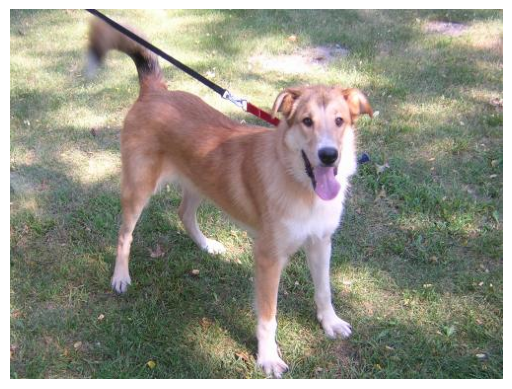

In [22]:
random_image_path = random.choice(all_image_paths)
print(f"Selected random image: {random_image_path}")

image = Image.open(random_image_path)
plt.imshow(image)
plt.axis('off')
plt.show()

### 3.1 Class Distribution

We check how many images belong to each class after the data cleaning step, to confirm the dataset remains balanced between cats and dogs.

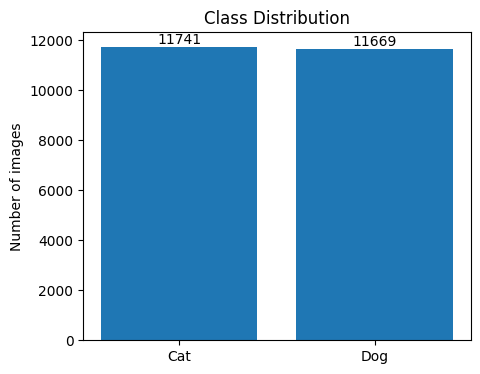

In [23]:
cat_count = len(list((data_dir / "Cat").glob("*.jpg")))
dog_count = len(list((data_dir / "Dog").glob("*.jpg")))

plt.figure(figsize=(5, 4))
bars = plt.bar(["Cat", "Dog"], [cat_count, dog_count])
plt.title("Class Distribution")
plt.ylabel("Number of images")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, str(height), ha="center", va="bottom")

plt.show()

The dataset remains well balanced after cleaning: 11,741 cat images and 11,669 dog images, a difference of less than 1%. This means we can train and evaluate the model using plain accuracy as a metric, without needing class weighting or resampling techniques to handle imbalance.

### 3.2 Sample Images from Each Class

To get a better sense of the data, we display a grid of random sample images from both classes.

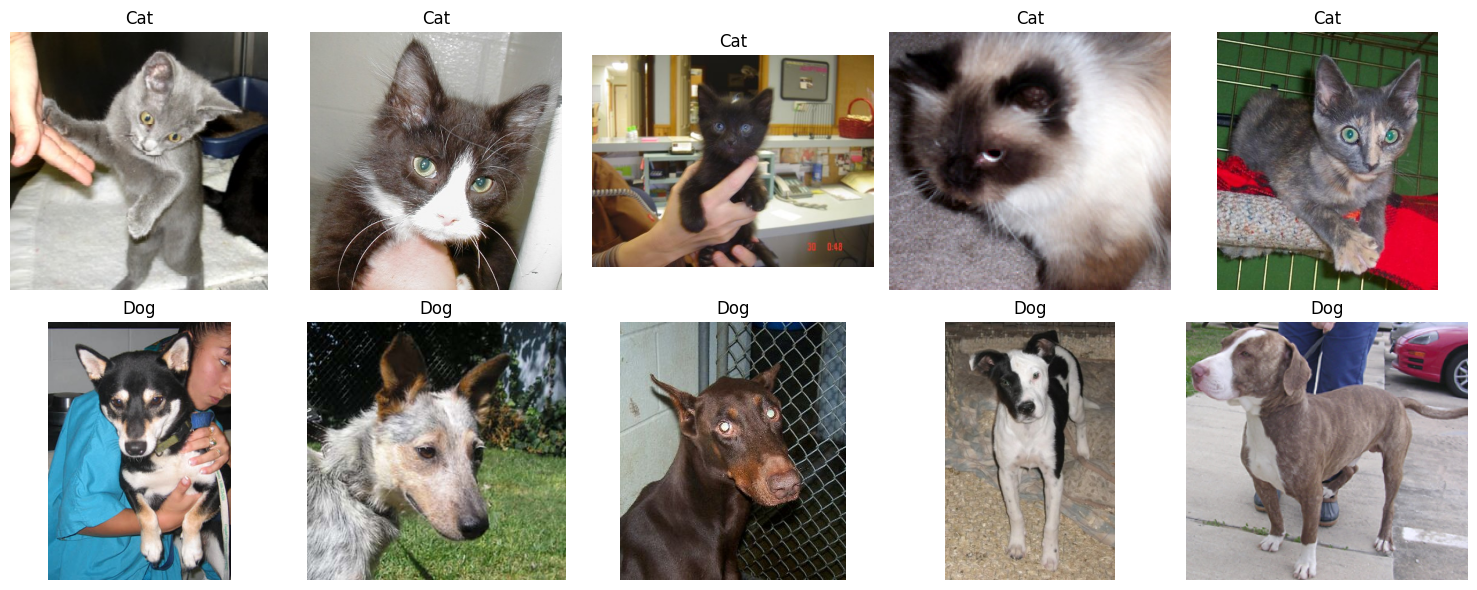

In [24]:
cat_paths = list((data_dir / "Cat").glob("*.jpg"))
dog_paths = list((data_dir / "Dog").glob("*.jpg"))

sample_cats = random.sample(cat_paths, 5)
sample_dogs = random.sample(dog_paths, 5)
sample_images = sample_cats + sample_dogs
sample_labels = ["Cat"] * 5 + ["Dog"] * 5

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, path, label in zip(axes.flatten(), sample_images, sample_labels):
    image = Image.open(path)
    ax.imshow(image)
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

The sample images confirm that this is a real-world, unfiltered dataset: photos vary widely in pose, background, lighting, and framing (close-up portraits, full-body shots, indoor and outdoor scenes). This diversity is useful for training a model that generalizes well, but it also means the model cannot rely on consistent backgrounds or camera angles to make predictions.

### 3.3 Image Dimensions Analysis

Real-world images in this dataset vary in size. Before deciding on a fixed input size for the model, we sample a subset of images and inspect the distribution of their widths and heights.

Width  - min: 58, max: 500, mean: 412.9
Height - min: 50, max: 500, mean: 366.7


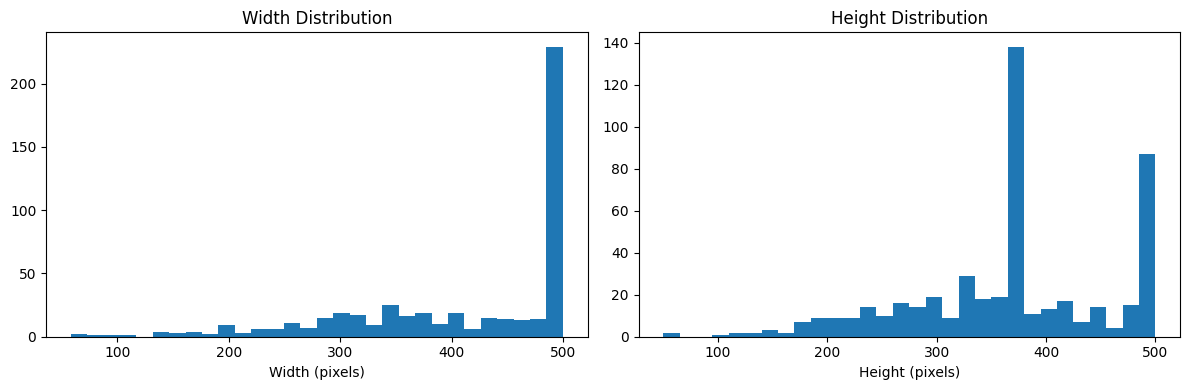

In [25]:
sample_size = 500
sampled_paths = random.sample(all_image_paths, sample_size)

widths = []
heights = []

for path in sampled_paths:
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

widths = np.array(widths)
heights = np.array(heights)

print(f"Width  - min: {widths.min()}, max: {widths.max()}, mean: {widths.mean():.1f}")
print(f"Height - min: {heights.min()}, max: {heights.max()}, mean: {heights.mean():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30)
axes[0].set_title("Width Distribution")
axes[0].set_xlabel("Width (pixels)")

axes[1].hist(heights, bins=30)
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Height (pixels)")

plt.tight_layout()
plt.show()

Image dimensions vary substantially: widths range from 58 to 500 pixels (mean 412.7) and heights from 50 to 500 pixels (mean 366.5). Both distributions are skewed toward the upper bound, with a large spike of images at exactly 500 pixels. This confirms that all images must be resized to a fixed input shape before being fed into the model, since a CNN requires consistent input dimensions.

### 3.4 Aspect Ratio Distribution

We also check the aspect ratio (width divided by height) of the sampled images, to see how far most images deviate from a square shape.

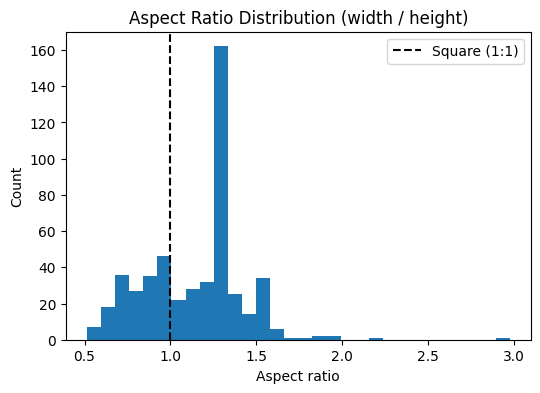

In [26]:
aspect_ratios = widths / heights

plt.figure(figsize=(6, 4))
plt.hist(aspect_ratios, bins=30)
plt.title("Aspect Ratio Distribution (width / height)")
plt.xlabel("Aspect ratio")
plt.ylabel("Count")
plt.axvline(1.0, color="black", linestyle="--", label="Square (1:1)")
plt.legend()
plt.show()

Most images have an aspect ratio between 0.5 and 2.0, with a clear peak around 1.3 to 1.4 (slightly wider than tall). Relatively few images are perfectly square (ratio of 1.0). Since the spread is moderate rather than extreme, a direct resize to a fixed square shape is a reasonable choice for this project, without requiring more complex padding or cropping strategies to preserve aspect ratio.

## 4. Data Preprocessing

Before training a model, the raw images need to be converted into a consistent format. Based on the EDA results, image sizes vary significantly, so all images will be resized to a fixed shape. Pixel values will be normalized to the [0, 1] range, and the data will be organized into a PyTorch `Dataset` and `DataLoader` pipeline for efficient batching during training.

### 4.1 Building the Sample List

We combine the cat and dog image paths into a single list of (path, label) pairs, using 0 for Cat and 1 for Dog, and shuffle the list so that both classes are mixed before splitting.

In [27]:
IMAGE_SIZE = 128 # chosen based on the EDA size distribution

In [28]:
cat_paths = list((data_dir / "Cat").glob("*.jpg"))
dog_paths = list((data_dir / "Dog").glob("*.jpg"))

all_samples = [(p, 0) for p in cat_paths] + [(p, 1) for p in dog_paths]
random.shuffle(all_samples)

print(f"Total samples: {len(all_samples)}")
print(f"Example: {all_samples[0]}")

Total samples: 23410
Example: (PosixPath('/root/.keras/datasets/kagglecatsanddogs_5340_extracted/PetImages/Dog/1206.jpg'), 1)


### 4.2 Train / Validation / Test Split

The shuffled samples are split into training (70%), validation (15%), and test (15%) sets using simple slicing, since the list is already randomly shuffled.

In [29]:
train_ratio = 0.7
val_ratio = 0.15
# remaining 0.15 goes to the test set

n_total = len(all_samples)
n_train = int(n_total * train_ratio)
n_val = int(n_total * val_ratio)

train_samples = all_samples[:n_train]
val_samples = all_samples[n_train:n_train + n_val]
test_samples = all_samples[n_train + n_val:]

print(f"Train samples: {len(train_samples)}")
print(f"Validation samples: {len(val_samples)}")
print(f"Test samples: {len(test_samples)}")

Train samples: 16387
Validation samples: 3511
Test samples: 3512


### 4.3 PyTorch Dataset Class

We define a custom PyTorch `Dataset` that loads an image from disk, converts it to RGB (a small number of images are grayscale), resizes it to a fixed shape, scales pixel values to the [0, 1] range, and converts it to a tensor in the (channels, height, width) format expected by PyTorch.

In [30]:
class CatsDogsDataset(Dataset):
    def __init__(self, samples, image_size=IMAGE_SIZE):
        self.samples = samples
        self.image_size = image_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        image = Image.open(path).convert("RGB")
        image = image.resize((self.image_size, self.image_size))

        image_array = np.array(image, dtype=np.float32) / 255.0
        image_tensor = torch.from_numpy(image_array).permute(2, 0, 1)

        return image_tensor, torch.tensor(label, dtype=torch.long)

### 4.4 Creating DataLoaders

The three datasets (train, validation, test) are wrapped in PyTorch `DataLoader` objects, which handle batching. The training loader shuffles the data on every epoch, while validation and test loaders keep a fixed order.

In [31]:
BATCH_SIZE = 32

In [32]:
train_dataset = CatsDogsDataset(train_samples)
val_dataset = CatsDogsDataset(val_samples)
test_dataset = CatsDogsDataset(test_samples)

In [33]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [34]:
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 513
Number of validation batches: 110
Number of test batches: 110


### 4.5 Sanity Check

Before moving on to the model, we verify that a batch from the training loader has the expected shape: batch size, 3 color channels, and the fixed image dimensions.

In [35]:
images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape}")
print(f"Batch label shape: {labels.shape}")

Batch image shape: torch.Size([32, 3, 128, 128])
Batch label shape: torch.Size([32])




We build a simple convolutional neural network from scratch using Keras, running on the PyTorch backend. The architecture uses three convolutional blocks with increasing filter counts, followed by global average pooling and a dense classification head. This serves as our baseline model before any transfer learning or further tuning is introduced.

## 5. Model Architecture

### 5.1 Data Format Configuration

Our PyTorch `Dataset` produces image tensors in (channels, height, width) format, following PyTorch convention. By default, Keras expects images in (height, width, channels) format instead. To avoid permuting every batch, we configure Keras to use the channels-first format globally, matching our existing data pipeline.

In [36]:
keras.config.set_image_data_format("channels_first")

### 5.2 Defining the CNN

The model consists of three convolutional blocks (16, 32, and 64 filters), each followed by max pooling to progressively reduce the spatial dimensions. Instead of flattening the final feature maps, we use global average pooling, which reduces the number of parameters and helps limit overfitting on this basic baseline. A dropout layer is added before the final output for additional regularization. Since this is a binary classification problem (cat vs dog), the output layer has a single unit with a sigmoid activation.

In [37]:
def build_cnn(image_size=IMAGE_SIZE):
    model = keras.Sequential([
        keras.Input(shape=(3, image_size, image_size)),

        layers.Conv2D(16, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=2),

        layers.Conv2D(32, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=2),

        layers.Conv2D(64, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])

    return model

In [38]:
model = build_cnn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 128, 128)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 64, 64)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 32, 32)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,809 (108.63 KB)

 Trainable params: 27,809 (108.63 KB)

 Non-trainable params: 0 (0.00 B)

### 5.3 Sanity Check

Before setting up training, we pass a single batch through the untrained model to confirm the output shape matches expectations: one probability value per image in the batch.

In [39]:
sample_images, sample_labels = next(iter(train_loader))
sample_output = model(sample_images)

In [40]:
print(f"Input batch shape: {sample_images.shape}")
print(f"Output shape: {sample_output.shape}")
print(f"Sample predictions (untrained model): {sample_output[:5]}")

Input batch shape: torch.Size([32, 3, 128, 128])
Output shape: torch.Size([32, 1])
Sample predictions (untrained model): tensor([[0.5050],
        [0.5048],
        [0.5062],
        [0.5042],
        [0.5052]], device='cuda:0', grad_fn=<SliceBackward0>)


The model summary confirms a lightweight baseline with 27,809 trainable parameters, small enough to train quickly even on limited compute. The sanity check confirms the pipeline works end-to-end: a batch of shape (32, 3, 128, 128) produces an output of shape (32, 1), with predictions close to 0.5 as expected from an untrained model with sigmoid output (since the model has not yet learned to distinguish the classes).

## 6. Training Setup

Before training, the model is compiled with a loss function, optimizer, and evaluation metric. Since this is binary classification with a sigmoid output, we use binary crossentropy as the loss function and Adam as the optimizer. We also add early stopping to prevent unnecessary training once the validation performance stops improving.

In [41]:
model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)

In [42]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

### 6.1 Training the Model

The model is trained for a fixed maximum number of epochs, using the training and validation `DataLoader` objects created earlier. Early stopping will halt training automatically if the validation loss stops improving.

In [43]:
EPOCHS = 15

In [44]:
history = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=EPOCHS,
    callbacks=[early_stopping],
)

Epoch 1/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 82s 157ms/step - accuracy: 0.5605 - loss: 0.6758 - val_accuracy: 0.6203 - val_loss: 0.6483
Epoch 2/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 80s 156ms/step - accuracy: 0.6199 - loss: 0.6465 - val_accuracy: 0.5708 - val_loss: 0.6690
Epoch 3/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 79s 154ms/step - accuracy: 0.6568 - loss: 0.6204 - val_accuracy: 0.6539 - val_loss: 0.6150
Epoch 4/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 77s 150ms/step - accuracy: 0.6830 - loss: 0.5965 - val_accuracy: 0.6725 - val_loss: 0.5965
Epoch 5/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 78s 152ms/step - accuracy: 0.7044 - loss: 0.5751 - val_accuracy: 0.7232 - val_loss: 0.5478
Epoch 6/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 78s 151ms/step - accuracy: 0.7225 - loss: 0.5519 - val_accuracy: 0.6813 - val_loss: 0.5862
Epoch 7/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 78s 152ms/step - accuracy: 0.7324 - loss: 0.5375 - val_accuracy: 0.7317 - val_loss: 0.5300
Epoch 8/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 78s 153ms/step - accuracy: 0.7428 - loss: 0

The baseline model reached a validation accuracy of approximately 79.83% after 15 epochs, with training accuracy at 78.78%. The close gap between training and validation metrics suggests the model is not significantly overfitting at this point. Since early stopping did not trigger and the validation loss was still decreasing at epoch 15, the model may benefit from additional training epochs in a later iteration.

### 6.2 Training and Loss Curves

To better understand the training process, we plot the training and validation accuracy and loss over the epochs. This helps visually confirm whether the model is still improving, has plateaued, or is starting to overfit.

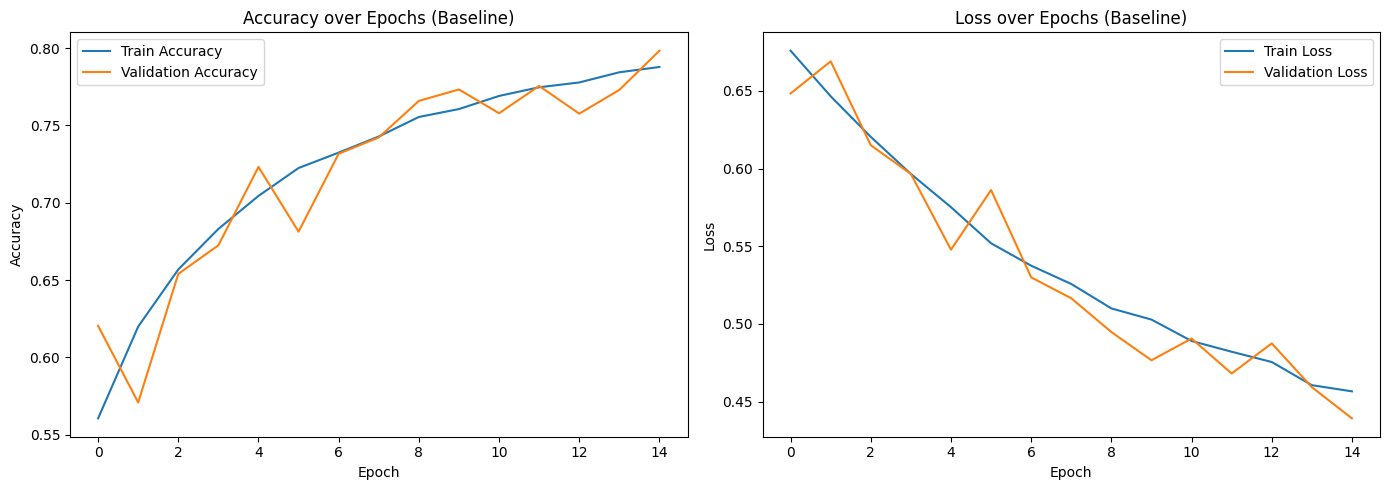

In [45]:
plot_training_curves(history, title_suffix=" (Baseline)")

Both accuracy curves rise together throughout training, showing steady learning progress. Validation accuracy is noticeably noisier than training accuracy, featuring fluctuations such as a temporary dip around epochs 11-13 before recovering sharply at epoch 14 (the 15th epoch) to reach approximately 79.83%. The validation loss follows a corresponding mirrored pattern with a brief upward bump around epochs 11-12 before dropping to its lowest point at epoch 14. Despite these local fluctuations, there is no sustained divergence between training and validation performance, confirming the model is not overfitting. Both curves continue to trend favorably at the final epoch, suggesting that additional training epochs could yield further performance gains.

## 7. Evaluation

We evaluate the trained model on the held-out test set, which was not used during training or for early stopping decisions. Predictions are compared against the true labels to compute a confusion matrix and standard classification metrics, all implemented manually with NumPy.

### 7.1 Generating Predictions on the Test Set

We run the trained model on every batch of the test set, collecting the predicted class (0 for Cat, 1 for Dog) alongside the true labels. Since the model outputs a sigmoid probability, predictions above 0.5 are classified as Dog, and predictions below 0.5 as Cat.

In [46]:
all_predictions, all_true_labels = predict_with_model(model, test_loader)

# Paths come directly from the dataset, in the same fixed order (shuffle=False)
all_paths = [path for path, _ in test_samples]
assert len(all_paths) == len(all_predictions), "Mismatch between paths and predictions length"

print(f"Total test predictions: {len(all_predictions)}")

Total test predictions: 3512


### 7.2 Confusion Matrix

The confusion matrix shows how many predictions fall into each combination of true and predicted class: true positives, true negatives, false positives, and false negatives.

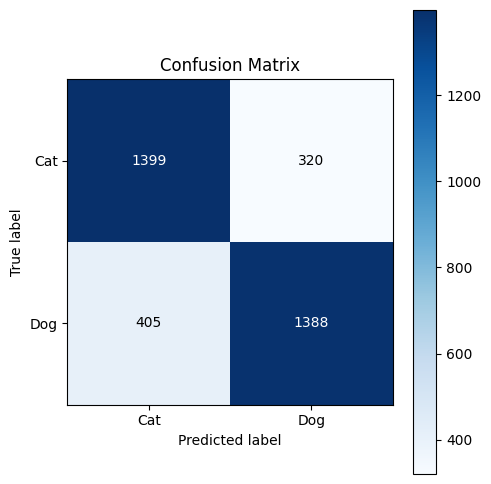

In [47]:
conf_matrix = compute_confusion_matrix(all_true_labels, all_predictions)
class_names = ["Cat", "Dog"]

plot_confusion_matrix(conf_matrix, class_names, title="Confusion Matrix")

Out of 1,719 cat images, 1,399 were correctly classified while 320 were misclassified as dogs. Out of 1,793 dog images, 1,388 were correctly classified while 405 were misclassified as cats. The errors are relatively balanced between the two classes, suggesting the model does not have a strong bias toward either class.

### 7.3 Classification Metrics

From the confusion matrix, we compute overall accuracy, along with per-class precision, recall, and F1-score. Precision measures how many predicted positives were correct, recall measures how many actual positives were found, and F1-score balances the two.

In [48]:
baseline_test_accuracy = compute_metrics(conf_matrix, class_names)

Overall Accuracy: 0.7936

Cat: precision=0.7755, recall=0.8138, f1=0.7942
Dog: precision=0.8126, recall=0.7741, f1=0.7929


The model achieves an overall test accuracy of 79.36%, closely matching the validation accuracy observed during training (0.7983), which confirms the model generalizes consistently to unseen data. Precision and recall are well balanced for both classes: cats have a precision of 0.7755 and a recall of 0.8138, while dogs have a precision of 0.8126 and a recall of 0.7741. The F1-scores for both classes are nearly identical (0.7942 for Cat, 0.7929 for Dog), indicating balanced performance across classes rather than one class being favored at the expense of the other.

### 7.4 Overfitting Check

We quantify the gap between training, validation, and test performance to check for signs of overfitting: a widening train-validation gap or a validation loss that starts increasing while training loss keeps decreasing.

In [49]:
check_overfitting(history, baseline_test_accuracy, model_name="Baseline CNN")

--- Baseline CNN ---
Final train accuracy: 0.7878
Final val accuracy:   0.7983
Best val accuracy (epoch 15): 0.7983
Test accuracy:        0.7936
Train-Val gap:        -0.0105
Val-Test gap:         0.0048
Val loss above its minimum at the last epoch: False


The train-validation gap is slightly negative (-0.0105), meaning validation accuracy is marginally higher than training accuracy-the opposite of what overfitting would produce. The validation loss was still at its minimum in the final epoch (Val loss above its minimum: False), confirming it had not started rising. Test accuracy (0.7936) is very close to the best validation accuracy (0.7983), with a val-test gap of only 0.0048. Together, these results show no evidence of overfitting for the baseline model - if anything, training could have continued further to improve performance.

### 7.5 Retraining with More Epochs

The overfitting check in Section 7.4 showed that the baseline model had not yet converged at epoch 15: validation loss was still at its minimum and had not started increasing. This suggests the model may benefit from additional training. Instead of guessing a fixed number of epochs, we set a generous upper bound and let early stopping determine the actual stopping point based on validation loss, with a slightly higher patience to tolerate the noisier validation curve observed earlier.

In [50]:
EXTENDED_EPOCHS = 40 # generous upper bound - early stopping decides the real stopping point

In [51]:
extended_model = build_cnn()

In [52]:
extended_model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)

extended_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,  # slightly higher than baseline, to tolerate noisier validation curve
    restore_best_weights=True,
)

In [53]:
extended_history = extended_model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=EXTENDED_EPOCHS,
    callbacks=[extended_early_stopping],
)

Epoch 1/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 78s 152ms/step - accuracy: 0.5900 - loss: 0.6674 - val_accuracy: 0.6440 - val_loss: 0.6355
Epoch 2/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 78s 152ms/step - accuracy: 0.6332 - loss: 0.6347 - val_accuracy: 0.6651 - val_loss: 0.6073
Epoch 3/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 78s 151ms/step - accuracy: 0.6645 - loss: 0.6092 - val_accuracy: 0.6878 - val_loss: 0.5835
Epoch 4/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 76s 149ms/step - accuracy: 0.6938 - loss: 0.5841 - val_accuracy: 0.7044 - val_loss: 0.5669
Epoch 5/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 77s 149ms/step - accuracy: 0.7065 - loss: 0.5692 - val_accuracy: 0.6915 - val_loss: 0.5770
Epoch 6/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 76s 148ms/step - accuracy: 0.7181 - loss: 0.5573 - val_accuracy: 0.7109 - val_loss: 0.5498
Epoch 7/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 76s 149ms/step - accuracy: 0.7276 - loss: 0.5465 - val_accuracy: 0.7371 - val_loss: 0.5231
Epoch 8/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 77s 149ms/step - accuracy: 0.7357 - loss: 0

### 7.5.1 Training and Loss Curves

To decide whether training for even more epochs would be worthwhile, we visualize the accuracy and loss curves over all 40 epochs.

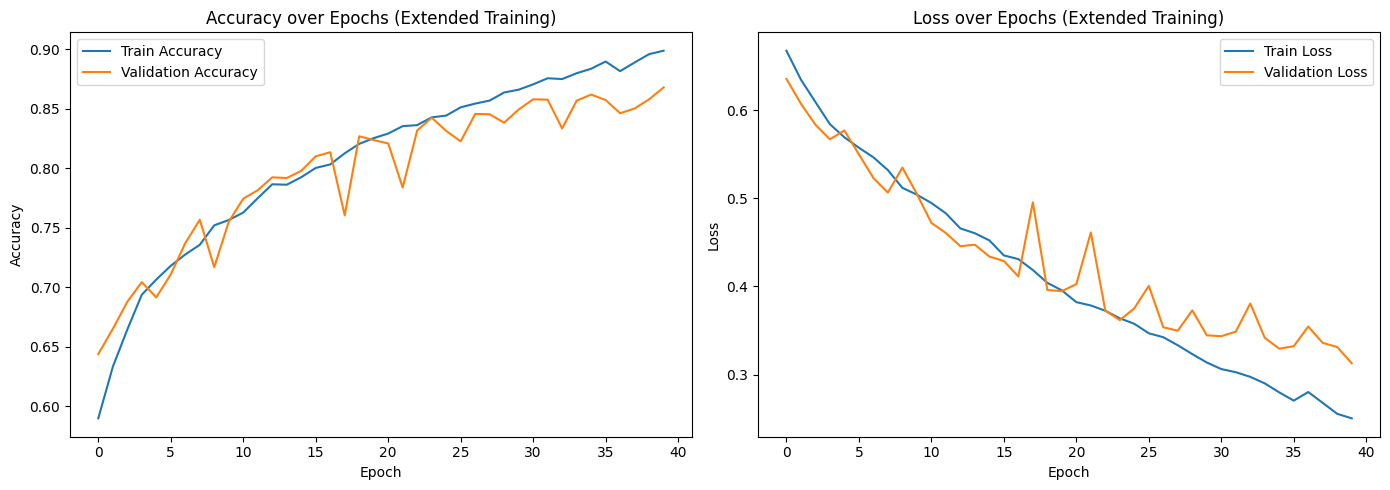

In [54]:
plot_training_curves(extended_history, title_suffix=" (Extended Training)")

The validation curves show several sharp spikes in validation loss throughout training, most notably a prominent spike around epoch 17, likely caused by particularly difficult validation batches. Despite this noise, the overall trend is a steady decrease in both training and validation loss through the later epochs.

Training was capped at 40 epochs rather than left to run until early stopping triggered naturally, for practical reasons: the improvement per additional epoch was already diminishing, each epoch costs around 80 seconds, and most importantly, the transfer learning model (Section 10) already achieves a test accuracy of 98.15% - far beyond what additional training on this from-scratch architecture is likely to reach. Given the limited time remaining for this project, continuing to train this specific model further would not meaningfully change the project's conclusions, so 40 epochs was accepted as a reasonable stopping point.

### 7.5.3 Confirming How Many Epochs Actually Ran

We check how many epochs were run before early stopping triggered, and at which epoch the best validation loss occurred.

In [55]:
report_early_stopping(extended_history, EXTENDED_EPOCHS)

Training completed all 40 epochs without early stopping triggering.
Best epoch (lowest val_loss): 40


(40, np.int64(40))

Training ran the full 40 epochs without early stopping triggering - at epoch 40, the model was still within its patience window of 5 epochs since the best validation loss (epoch 37). This confirms that the 40-epoch cap, not early stopping, was the actual stopping condition, consistent with the decision explained in Section 7.5.1.

### 7.5.4 Evaluating the Extended Model

We evaluate the extended model on the same held-out test set, reusing the confusion matrix and metrics functions.

In [56]:
ext_predictions, ext_true_labels = predict_with_model(extended_model, test_loader)
ext_conf_matrix = compute_confusion_matrix(ext_true_labels, ext_predictions)
extended_test_accuracy = compute_metrics(ext_conf_matrix, class_names)

Overall Accuracy: 0.8642

Cat: precision=0.8723, recall=0.8464, f1=0.8592
Dog: precision=0.8568, recall=0.8812, f1=0.8688


The extended model (40 epochs) achieves a test accuracy of 86.42%, a substantial improvement of 7.06 percentage points over the original 15-epoch baseline (79.36%). Precision, recall, and F1-scores also improved for both classes and became more balanced (Cat: precision 0.8723, recall 0.8464, f1 0.8592; Dog: precision 0.8568, recall 0.8812, f1 0.8688), compared to the larger recall gap seen in the original baseline. This confirms the earlier finding that the baseline model had not yet converged at 15 epochs.

For visual consistency with the other evaluated models, we also plot the confusion matrix for the extended model.

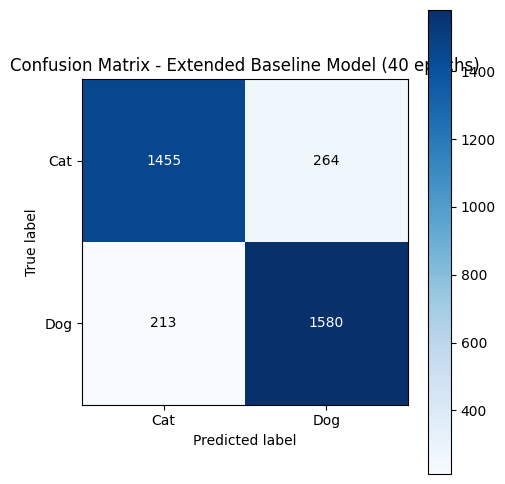

In [57]:
plot_confusion_matrix(ext_conf_matrix, class_names, title="Confusion Matrix - Extended Baseline Model (40 epochs)")

Out of 1,719 cat images, 1,455 were correctly classified while 264 were misclassified as dogs. Out of 1,793 dog images, 1,580 were correctly classified while 213 were misclassified as cats. Compared to the original baseline (320 cat errors, 405 dog errors), both error counts dropped substantially, with the largest improvement in correctly identifying dogs.

### 7.5.5 Overfitting Check on the Extended Model

In [58]:
check_overfitting(extended_history, extended_test_accuracy, model_name="Extended Baseline CNN")

--- Extended Baseline CNN ---
Final train accuracy: 0.8987
Final val accuracy:   0.8678
Best val accuracy (epoch 40): 0.8678
Test accuracy:        0.8642
Train-Val gap:        0.0309
Val-Test gap:         0.0037
Val loss above its minimum at the last epoch: False


The train-validation gap has grown to 0.0309 (compared to -0.0105 for the original 15-epoch baseline). The output Val loss above its minimum at the last epoch: False confirms that validation loss remained at its minimum and did not rise at the final epoch. Furthermore, the val-test gap remains small (0.0037), and test accuracy (0.8642) is very close to the best validation accuracy (0.8678), confirming that restore_best_weights=True correctly preserved the model from its best-performing epoch.

## 8. Error Analysis

Beyond aggregate metrics, it is useful to visually inspect specific misclassified images. This can reveal patterns in the model's mistakes, such as difficult poses, unusual lighting, occlusion, or ambiguous images that even a human might find hard to classify correctly.

### 8.1 Identifying Misclassified Images

We compare the test set predictions against the true labels to find which images were misclassified, and split them into two groups: cats misclassified as dogs, and dogs misclassified as cats.

In [59]:
misclassified_indices, false_positive_idx, false_negative_idx = identify_misclassified(all_true_labels, all_predictions)

Total misclassified images: 725 out of 3512
Cat misclassified as Dog: 320
Dog misclassified as Cat: 405


### 8.2 Visualizing Misclassified Images

We sample a few examples from each error type and display them with their true and predicted labels, to look for any visible patterns behind the mistakes.

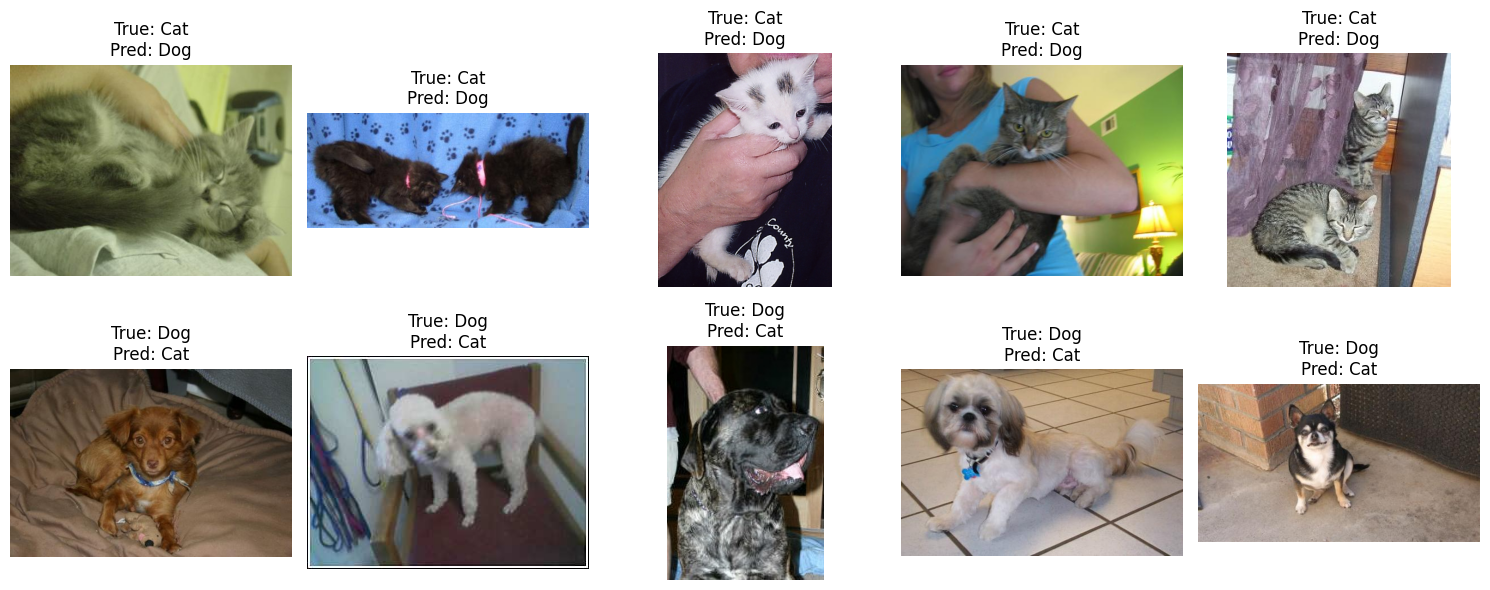

In [60]:
plot_misclassified_grid(all_paths, all_true_labels, all_predictions, false_positive_idx, false_negative_idx, class_names)

The misclassified examples reveal several recurring patterns. Several "Cat predicted as Dog" errors involve unusual poses or contexts: two kittens photographed together on furniture, a cat mid-motion climbing on a table, and a cat photographed inside a shelter cage - all cases where the pose or background differs from a typical portrait shot. Coloring also plays a role: black-and-white patched cats appear visually similar to black-and-white patched dog breeds, which may explain some of these errors.

The "Dog predicted as Cat" errors follow a related pattern: several images are tight close-up crops of a dog's face or head, which removes the body proportions (ear shape, snout length, overall build) that are normally strong cues for distinguishing the two species. A curled-up puppy and a slender, fox-like dog photographed from a low angle also resemble typical cat poses and body shapes.

Overall, the errors are not random - they cluster around images where pose, framing, or coloring reduce the visual cues that typically separate cats from dogs, rather than reflecting a systematic bias in the model.

### 8.3 Prediction Confidence on Misclassified Images

To understand whether the model's mistakes are "close calls" or confident errors, we look at the raw sigmoid output (before thresholding at 0.5) for the misclassified test images. Predictions close to 0.5 indicate genuine uncertainty, while predictions close to 0 or 1 indicate the model was confidently wrong.

Mean distance from decision boundary (0.5): 0.1901
Median distance from decision boundary (0.5): 0.1719


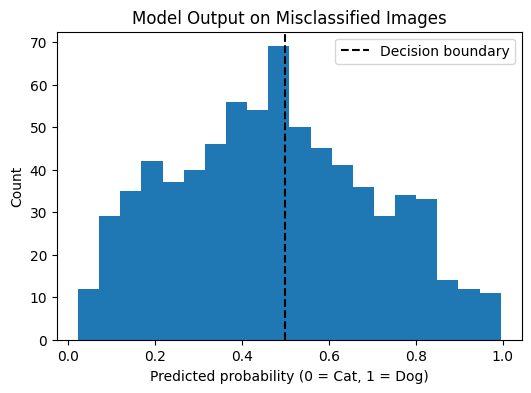

In [61]:
misclassified_confidences = compute_misclassified_confidences(model, test_dataset, misclassified_indices)
distance_from_boundary = plot_confidence_histogram(misclassified_confidences, title="Model Output on Misclassified Images")

The mean distance from the decision boundary is 0.1901 (median 0.1719), meaning the model's misclassified predictions are, on average, only moderately far from the 0.5 threshold rather than being wildly confident in the wrong direction. The histogram confirms this: the largest concentration of errors falls close to the decision boundary, consistent with genuinely ambiguous images where distinguishing cat from dog is difficult even visually.

At the same time, there is a noticeable spread toward both extremes (0.0 and 1.0), meaning a meaningful subset of errors involved the model being quite confident despite being wrong. This suggests the model is occasionally confidently mistaking certain images (likely images sharing strong visual cues with the opposite class, as seen in the sample grid) rather than just struggling with borderline cases.

### 8.4 Error Analysis on the Extended Model

We repeat the same error analysis performed on the original baseline, this time for the extended model, to see whether the additional training changed the nature of the model's mistakes or simply reduced their number.

#### 8.4.1 Identifying Misclassified Images

In [62]:
ext_misclassified_indices, ext_false_positive_idx, ext_false_negative_idx = identify_misclassified(ext_true_labels, ext_predictions)

Total misclassified images: 477 out of 3512
Cat misclassified as Dog: 264
Dog misclassified as Cat: 213


The extended model misclassifies 477 out of 3,512 test images (13.6% error rate), compared to 725 misclassifications for the original 15-epoch baseline shown earlier in this section - a substantial reduction. Unlike the original baseline, where dog-as-cat errors slightly outnumbered cat-as-dog errors, the extended model shows the opposite pattern (264 cats misclassified as dogs vs 213 dogs misclassified as cats), with a more pronounced improvement in correctly identifying dogs.

#### 8.4.2 Visualizing Misclassified Images

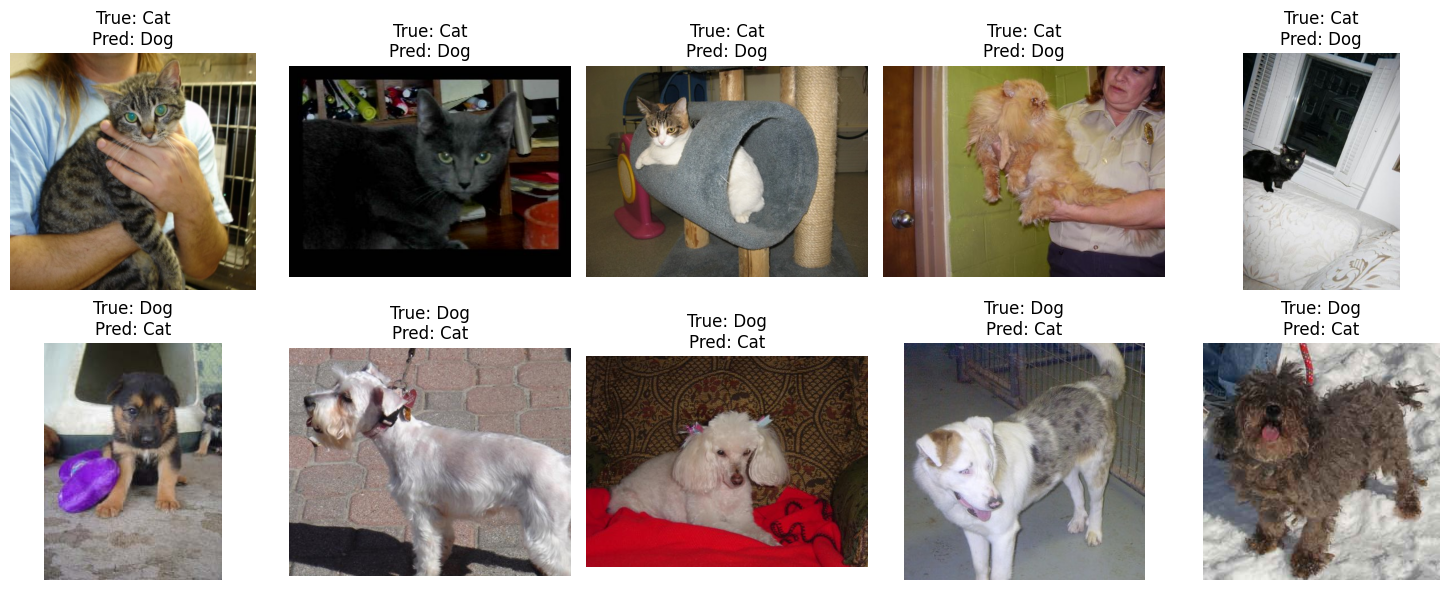

In [63]:
plot_misclassified_grid(all_paths, ext_true_labels, ext_predictions, ext_false_positive_idx, ext_false_negative_idx, class_names)

The "Cat predicted as Dog" errors show a recurring pattern of human occlusion: two of the five examples show a person holding the cat, partially obscuring its body shape and fur pattern. The remaining cases include a cat photographed inside a tunnel-shaped cat tree (an unusual silhouette), a black cat in low light near a window, and a close-up black cat portrait with minimal background context.

The "Dog predicted as Cat" errors cluster around poses and settings more typical of cat photography: a small puppy sitting calmly with a toy, a white dog lying curled on a cushion, and a wiry-coated dog standing calmly on a leash - all relatively small, calm, low-profile poses rather than typical active "dog" body language. One image also shows a dog near cage or shelter bars, echoing a pattern seen in the cat errors above.

Overall, occlusion from human interaction and atypical, calm poses remain the dominant source of errors for this model, distinct from the more varied causes (lighting, framing, coloring) seen in the original baseline.

#### 8.4.3 Prediction Confidence on Misclassified Images

As with the original baseline, we check whether the extended model's mistakes are close calls or confident errors, using the raw sigmoid output before thresholding.

Mean distance from decision boundary (0.5): 0.2340
Median distance from decision boundary (0.5): 0.2230


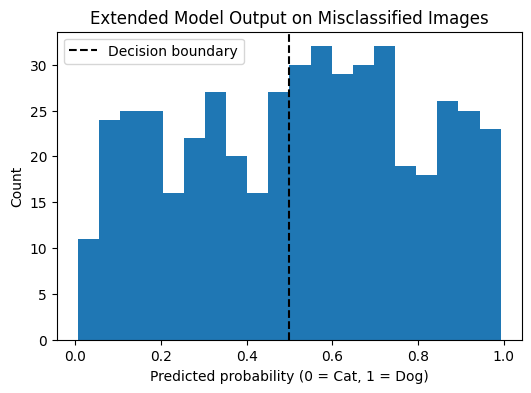

In [64]:
ext_misclassified_confidences = compute_misclassified_confidences(extended_model, test_dataset, ext_misclassified_indices)
ext_distance_from_boundary = plot_confidence_histogram(ext_misclassified_confidences, title="Extended Model Output on Misclassified Images")

The mean distance from the decision boundary is 0.2340 (median 0.2230) - notably higher than the original baseline's 0.1901. This means that while the extended model makes far fewer mistakes overall, the mistakes it does make tend to be somewhat more confident on average than the baseline's errors. The histogram shows a more spread-out distribution, with counts remaining fairly high even in the 0.6-1.0 range, rather than concentrating tightly around 0.5. This suggests that with more training, the model has become better at correctly handling ambiguous cases near the boundary, leaving behind a smaller set of harder errors where strong but misleading visual cues (such as the overhead angles and low-contrast images seen above) push the model toward a confident but incorrect prediction.

## 9. Data Augmentation

Data augmentation artificially increases the diversity of the training data by applying random transformations (flips, rotations, zoom) to images during training. This can improve generalization and reduce overfitting, especially for a model trained from scratch. We rebuild the baseline CNN architecture with augmentation layers included, retrain it under the same conditions as the original baseline, and compare the results.

### 9.1 Defining Augmentation Layers

We use Keras preprocessing layers for augmentation: random horizontal flips, small random rotations, and random zoom. These layers are only active during training (`model.fit`) and are automatically skipped during evaluation and inference, so validation and test images remain unmodified.

In [65]:
def build_cnn_with_augmentation(image_size=IMAGE_SIZE):
    model = keras.Sequential([
        keras.Input(shape=(3, image_size, image_size)),

        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        layers.Conv2D(16, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=2),

        layers.Conv2D(32, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=2),

        layers.Conv2D(64, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])

    return model

In [66]:
augmented_model = build_cnn_with_augmentation()
augmented_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 3, 128, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 3, 128, 128)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 3, 128, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 128, 128)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 64, 64)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 32, 32)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,809 (108.63 KB)

 Trainable params: 27,809 (108.63 KB)

 Non-trainable params: 0 (0.00 B)

### 9.2 Visualizing Augmented Images

Before training, we visually confirm the augmentation layers work as expected by passing the same image through them multiple times and displaying the results side by side.

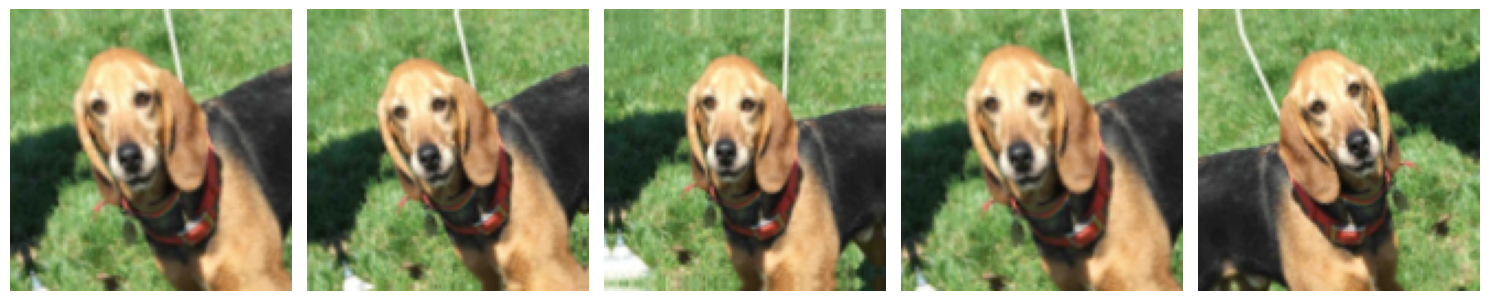

In [67]:
sample_image, _ = train_dataset[0]
sample_batch = sample_image.unsqueeze(0)

augmentation_layers = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for ax in axes:
    augmented = augmentation_layers(sample_batch, training=True)
    augmented_image = augmented[0].detach().cpu().numpy().transpose(1, 2, 0)
    ax.imshow(np.clip(augmented_image, 0, 1))
    ax.axis("off")

plt.tight_layout()
plt.show()

### 9.3 Training the Augmented Model

The augmented model is trained under the same conditions as the original baseline (same image size, batch size, optimizer, loss function, and number of epochs), so that any difference in results can be attributed to the augmentation rather than a change in training setup.

In [68]:
augmented_model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)

augmented_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

In [69]:
augmented_history = augmented_model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=EPOCHS,
    callbacks=[augmented_early_stopping],
)

Epoch 1/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 140s 273ms/step - accuracy: 0.5544 - loss: 0.6822 - val_accuracy: 0.5654 - val_loss: 0.6708
Epoch 2/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 140s 273ms/step - accuracy: 0.6110 - loss: 0.6585 - val_accuracy: 0.6220 - val_loss: 0.6439
Epoch 3/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 139s 271ms/step - accuracy: 0.6411 - loss: 0.6348 - val_accuracy: 0.6616 - val_loss: 0.6146
Epoch 4/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 139s 271ms/step - accuracy: 0.6664 - loss: 0.6126 - val_accuracy: 0.6725 - val_loss: 0.5945
Epoch 5/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 139s 271ms/step - accuracy: 0.6835 - loss: 0.5963 - val_accuracy: 0.6539 - val_loss: 0.6175
Epoch 6/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 139s 271ms/step - accuracy: 0.6985 - loss: 0.5821 - val_accuracy: 0.7172 - val_loss: 0.5542
Epoch 7/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 138s 270ms/step - accuracy: 0.7075 - loss: 0.5681 - val_accuracy: 0.7126 - val_loss: 0.5506
Epoch 8/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 139s 270ms/step - accuracy: 0.7208 -

The augmented model converges much more slowly than the baseline: training accuracy starts at 55.44% in epoch 1, but climbs steadily, reaching 76.01% by epoch 15, with validation accuracy at 74.99% and validation loss at 0.5088. Unlike the baseline, which reached roughly 80% accuracy in the same number of epochs, the augmented model appears to need more training time to fully benefit from the added data variability - the harder, more varied training signal from augmentation slows convergence within a fixed epoch budget.

### 9.4 Evaluating the Augmented Model

We evaluate the augmented model on the same held-out test set used for the baseline and transfer learning models, reusing the confusion matrix and metrics functions defined earlier.

In [70]:
aug_predictions, aug_true_labels = predict_with_model(augmented_model, test_loader)
aug_conf_matrix = compute_confusion_matrix(aug_true_labels, aug_predictions)
compute_metrics(aug_conf_matrix, class_names)

Overall Accuracy: 0.7417

Cat: precision=0.6975, recall=0.8342, f1=0.7597
Dog: precision=0.8043, recall=0.6531, f1=0.7208


np.float64(0.7417425968109339)

The augmented model achieves a test accuracy of 74.17%, lower than the non-augmented baseline (79.36%). Interestingly, cat recall actually improves slightly with augmentation (from 81.38% baseline to 83.42% augmented), while the drop is concentrated almost entirely in dog recall, which falls sharply from 77.41% (baseline) to 65.31% (augmented) - the model has become noticeably more likely to misclassify dogs as cats. Precision and recall are also less balanced overall (Cat: precision 0.6975, recall 0.8342, f1 0.7597; Dog: precision 0.8043, recall 0.6531, f1 0.7208).

Contrary to expectations, data augmentation did not improve on the baseline in this setup - test accuracy dropped from 79.36% to 74.17%, a decrease of 5.19 percentage points. As seen in Section 9.3, the augmented model was still actively improving at epoch 15 and had not yet converged, unlike the baseline. This suggests the result is not evidence that augmentation is harmful in general, but rather that the fixed 15-epoch budget suited to the baseline was insufficient for the harder, more varied training signal introduced by augmentation.

### 9.5 Retraining the Augmented Model with More Epochs

Section 9.5 suggested that the augmented model underperformed not because augmentation is harmful, but because it had not yet converged within the original 15-epoch budget. To test this directly, we retrain the augmented model with the same generous epoch upper bound and early stopping strategy used for the extended baseline model, and compare the result to both the original augmented model and the baseline.

In [71]:
extended_augmented_model = build_cnn_with_augmentation()

In [72]:
extended_augmented_model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)

extended_augmented_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

In [73]:
extended_augmented_history = extended_augmented_model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=EXTENDED_EPOCHS,
    callbacks=[extended_augmented_early_stopping],
)

Epoch 1/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 141s 274ms/step - accuracy: 0.5446 - loss: 0.6858 - val_accuracy: 0.5993 - val_loss: 0.6708
Epoch 2/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 141s 275ms/step - accuracy: 0.5901 - loss: 0.6682 - val_accuracy: 0.6115 - val_loss: 0.6478
Epoch 3/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 142s 277ms/step - accuracy: 0.6293 - loss: 0.6436 - val_accuracy: 0.6138 - val_loss: 0.6460
Epoch 4/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 143s 279ms/step - accuracy: 0.6638 - loss: 0.6140 - val_accuracy: 0.6619 - val_loss: 0.6103
Epoch 5/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 141s 276ms/step - accuracy: 0.6876 - loss: 0.5943 - val_accuracy: 0.6981 - val_loss: 0.5837
Epoch 6/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 140s 272ms/step - accuracy: 0.6968 - loss: 0.5803 - val_accuracy: 0.7061 - val_loss: 0.5659
Epoch 7/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 141s 274ms/step - accuracy: 0.7113 - loss: 0.5650 - val_accuracy: 0.7015 - val_loss: 0.5796
Epoch 8/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 143s 278ms/step - accuracy: 0.7146 -

### 9.5.1 Confirming How Many Epochs Actually Ran

In [74]:
report_early_stopping(extended_augmented_history, EXTENDED_EPOCHS)

Training completed all 40 epochs without early stopping triggering.
Best epoch (lowest val_loss): 40


(40, np.int64(40))

Unlike the earlier extended baseline model, training here completed all 40 epochs without early stopping triggering, with the best validation loss occurring at the final epoch (epoch 40). This suggests the augmented model may still benefit from even more training time - the added data variability from augmentation appears to require a longer training horizon than the baseline needed.

### 9.5.2 Evaluating the Extended Augmented Model

In [75]:
ext_aug_predictions, ext_aug_true_labels = predict_with_model(extended_augmented_model, test_loader)
ext_aug_conf_matrix = compute_confusion_matrix(ext_aug_true_labels, ext_aug_predictions)
extended_augmented_test_accuracy = compute_metrics(ext_aug_conf_matrix, class_names)

Overall Accuracy: 0.8121

Cat: precision=0.7754, recall=0.8674, f1=0.8188
Dog: precision=0.8565, recall=0.7591, f1=0.8048


The extended augmented model reaches a test accuracy of 81.21%, an improvement of 7.04 percentage points over the original 15-epoch augmented model (74.17%), and now actually exceeds the non-augmented baseline (79.36%) by 1.85 percentage points. Precision, recall, and F1-scores are also more balanced across classes (Cat: precision 0.7754, recall 0.8674, f1 0.8188; Dog: precision 0.8565, recall 0.7591, f1 0.8048) than the original augmented model's more skewed results. This confirms that augmentation itself was not the problem - the model simply needed substantially more epochs to fully benefit from the added data variability, and once given that time, it slightly outperforms the non-augmented baseline.

### 9.5.3 Overfitting Check on the Extended Augmented Model

In [76]:
check_overfitting(extended_augmented_history, extended_augmented_test_accuracy, model_name="Extended Augmented CNN")

--- Extended Augmented CNN ---
Final train accuracy: 0.8247
Final val accuracy:   0.8203
Best val accuracy (epoch 40): 0.8203
Test accuracy:        0.8121
Train-Val gap:        0.0045
Val-Test gap:         0.0082
Val loss above its minimum at the last epoch: False


The train-validation gap is small (0.0045), and validation loss is at its minimum at the final epoch (`Val loss above its minimum: False`) - unlike the transfer learning model, there is no evidence of overfitting here, consistent with training having been capped before any degradation began. The val-test gap is also small (0.0082), with test accuracy (0.8121) closely matching the final/best validation accuracy (0.8203). This confirms the model was still learning productively through all 40 epochs without drifting into overfitting - unlike the extended baseline (Section 7.5.5), which showed a larger train-validation gap (0.0309) after the same number of epochs, the augmented model's regularizing effect appears to keep it further from overfitting even after extended training.

### 9.6 Limitations of the Augmentation Used

While extending training resolved most of the performance gap, it is worth noting that the augmentation configuration used in this project (`RandomFlip("horizontal")`, `RandomRotation(0.1)`, `RandomZoom(0.1)`) is relatively conservative, which likely explains why its benefit was modest even after proper convergence:

- **Small transformation ranges**: a rotation factor of 0.1 allows only mild rotations, and a zoom factor of 0.1 allows only a 10% zoom range. As seen in the sample visualization (Section 9.2), the resulting images often look nearly identical to the original, providing limited additional diversity to the training set.
- **No color or lighting variation**: the augmentation pipeline does not vary brightness, contrast, or color, even though the EDA (Section 3.2) showed the dataset contains substantial lighting and color variation across real-world photos. Adding `RandomBrightness` or `RandomContrast` could better prepare the model for this variation.
- **No occlusion or cropping simulation**: techniques like random cropping or cutout, which force the model to rely on partial visual information, were not used. Given that the error analysis (Section 8) found close-up crops and partial views to be a common source of mistakes, this type of augmentation could be particularly relevant for this dataset.
- **Fixed augmentation strength throughout training**: the same augmentation intensity was applied from epoch 1 to the final epoch, rather than gradually increasing it (a common strategy that eases the model into harder training examples). This may partly explain the slower convergence observed in Section 9.6.1.
- **Small model capacity**: with only 27,809 trainable parameters, the baseline architecture may lack the capacity to fully exploit the additional diversity introduced by augmentation, regardless of how it is tuned. A larger from-scratch architecture might benefit more from stronger augmentation, though this was not tested given time constraints.

These limitations suggest that a stronger, more varied augmentation policy combined with a larger model could potentially close more of the gap to the baseline - and this is left as a direction for future work (Section 11) rather than explored further here, given the far superior results already achieved through transfer learning (Section 10).

## 10. Fine-Tuning a Pretrained Model

The baseline CNN trained from scratch reached a test accuracy of 79.36%. To explore whether performance can be improved, we fine-tune a pretrained MobileNetV2 backbone (trained on ImageNet) instead of training a network from scratch. Since pretrained features already encode general visual patterns (edges, textures, shapes), this typically leads to better accuracy with less training time.

### 10.1 Preparing Data at a Higher Resolution

Pretrained ImageNet models generally perform better with larger input images than our baseline's 128x128. We create a separate set of DataLoaders at 160x160, reusing the existing `CatsDogsDataset` class with a different image size.

In [77]:
TRANSFER_IMAGE_SIZE = 160

In [78]:
train_dataset_tl = CatsDogsDataset(train_samples, image_size=TRANSFER_IMAGE_SIZE)
val_dataset_tl = CatsDogsDataset(val_samples, image_size=TRANSFER_IMAGE_SIZE)
test_dataset_tl = CatsDogsDataset(test_samples, image_size=TRANSFER_IMAGE_SIZE)

In [79]:
train_loader_tl = DataLoader(train_dataset_tl, batch_size=BATCH_SIZE, shuffle=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=BATCH_SIZE, shuffle=False)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=BATCH_SIZE, shuffle=False)

In [80]:
print(f"Training batches: {len(train_loader_tl)}")

Training batches: 513


### 10.2 Building the Transfer Learning Model

We load MobileNetV2 with ImageNet weights, excluding its original classification head. The backbone is frozen (its weights are not updated), so only a new, small classification head is trained on top. Since our data pipeline already scales pixel values to [0, 1], we add a rescaling layer to match the [-1, 1] range MobileNetV2 expects.

In [81]:
def build_transfer_model(image_size=TRANSFER_IMAGE_SIZE):
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(3, image_size, image_size),
    )

    base_model.trainable = False  # freeze the pretrained backbone

    model = keras.Sequential([
        keras.Input(shape=(3, image_size, image_size)),
        layers.Rescaling(scale=2.0, offset=-1.0),  # [0, 1] -> [-1, 1]
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])

    return model

In [82]:
transfer_model = build_transfer_model()
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 3, 160, 160)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 1280, 5, 5)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

The transfer learning model has 2,340,033 total parameters, but only 82,049 of them are trainable, since the MobileNetV2 backbone (2,257,984 parameters) remains frozen. This means training only updates the small classification head (a dense layer of 64 units plus the final output layer), which keeps training fast despite the much larger overall model size.

### 10.3 Training the Transfer Learning Model

Only the new classification head has trainable parameters, since the backbone is frozen. This makes training much faster than the baseline model, and typically requires fewer epochs to converge.

In [83]:
transfer_model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)

transfer_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

In [84]:
TRANSFER_EPOCHS = 10

In [85]:
transfer_history = transfer_model.fit(
    train_loader_tl,
    validation_data=val_loader_tl,
    epochs=TRANSFER_EPOCHS,
    callbacks=[transfer_early_stopping],
)

Epoch 1/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 140s 272ms/step - accuracy: 0.9760 - loss: 0.0667 - val_accuracy: 0.9803 - val_loss: 0.0527
Epoch 2/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 143s 278ms/step - accuracy: 0.9844 - loss: 0.0425 - val_accuracy: 0.9815 - val_loss: 0.0527
Epoch 3/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 140s 272ms/step - accuracy: 0.9875 - loss: 0.0333 - val_accuracy: 0.9792 - val_loss: 0.0542
Epoch 4/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 143s 279ms/step - accuracy: 0.9907 - loss: 0.0276 - val_accuracy: 0.9826 - val_loss: 0.0519
Epoch 5/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 142s 278ms/step - accuracy: 0.9925 - loss: 0.0224 - val_accuracy: 0.9838 - val_loss: 0.0529
Epoch 6/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 140s 274ms/step - accuracy: 0.9941 - loss: 0.0177 - val_accuracy: 0.9821 - val_loss: 0.0557
Epoch 7/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 139s 272ms/step - accuracy: 0.9955 - loss: 0.0139 - val_accuracy: 0.9812 - val_loss: 0.0555


The transfer learning model converges almost immediately: it reaches 97.60% training accuracy and 98.03% validation accuracy already in epoch 1, since the frozen MobileNetV2 backbone provides strong, ready-made visual features. Training accuracy keeps climbing steadily through epoch 7 (99.55%), but validation loss reaches its lowest point at epoch 4 (0.0519) and fluctuates upward afterward (0.0529, 0.0557, 0.0555). This is a sign of the classification head starting to mildly overfit past epoch 4 - exactly the situation early stopping is designed to catch, since it will restore the weights from the best-performing epoch rather than the final one.

### 10.3.1 Confirming Early Stopping Behavior

Since `TRANSFER_EPOCHS = 10` was set as an upper bound, we check how many epochs actually ran, to confirm whether early stopping triggered before reaching that limit.

In [86]:
report_early_stopping(transfer_history, TRANSFER_EPOCHS)

Early stopping triggered: training stopped after 7 out of 10 epochs.
Best epoch (lowest val_loss): 4


(7, np.int64(4))

### 10.4 Evaluating the Transfer Learning Model

We evaluate the fine-tuned model on the same held-out test set, reusing the confusion matrix and metrics functions defined earlier in the Evaluation section.

In [87]:
tl_predictions, tl_true_labels = predict_with_model(transfer_model, test_loader_tl)
tl_conf_matrix = compute_confusion_matrix(tl_true_labels, tl_predictions)
transfer_test_accuracy = compute_metrics(tl_conf_matrix, class_names)

Overall Accuracy: 0.9815

Cat: precision=0.9853, recall=0.9767, f1=0.9810
Dog: precision=0.9779, recall=0.9861, f1=0.9819


The fine-tuned transfer learning model achieves a test accuracy of 98.15%, with precision, recall, and F1-scores above 0.97 for both classes (Cat: precision 0.9853, recall 0.9767, f1 0.9810; Dog: precision 0.9779, recall 0.9861, f1 0.9819). Performance is almost perfectly balanced between the two classes, with cats showing slightly higher precision and dogs slightly higher recall, but the gap is minimal compared to the baseline model.

For visual consistency with the baseline evaluation, we also plot the confusion matrix for the transfer learning model.

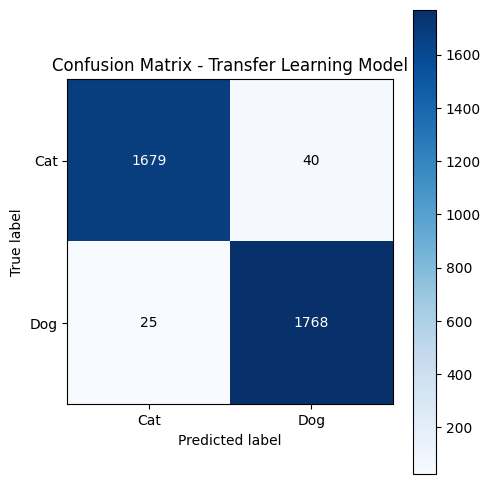

In [89]:
plot_confusion_matrix(tl_conf_matrix, class_names, title="Confusion Matrix - Transfer Learning Model")

Out of 1,719 cat images, 1,679 were correctly classified while only 40 were misclassified as dogs. Out of 1,793 dog images, 1,768 were correctly classified while only 25 were misclassified as cats. Errors are extremely rare and fairly evenly distributed between the two classes (40 vs 25), a stark contrast to the baseline model, where hundreds of images were misclassified in each direction. This confirms that the pretrained MobileNetV2 features generalize very well to this task with minimal confusion between classes.

Compared to the baseline model (79.36% test accuracy), the fine-tuned transfer learning model reaches 98.15% - an improvement of 18.79 percentage points. Precision, recall, and F1-scores are also far more balanced across classes for the transfer learning model: the baseline showed a noticeable gap between cat recall (81.38%) and dog recall (77.41%), whereas the transfer learning model keeps both classes within 1 percentage point of each other (Cat F1 0.9810, Dog F1 0.9819). This confirms that leveraging pretrained ImageNet features is dramatically more effective than training a small CNN from scratch on this dataset size, and explains why fine-tuning was explored as a follow-up after data augmentation (Section 9) failed to meaningfully improve on the baseline within the original epoch budget.

### 10.6 Overfitting Check

As with the baseline model, we quantify the gap between training, validation, and test performance for the transfer learning model, to check whether the mild upward trend in validation loss observed in Section 10.3 indicates meaningful overfitting.

In [90]:
check_overfitting(transfer_history, transfer_test_accuracy, model_name="Transfer Learning Model")

--- Transfer Learning Model ---
Final train accuracy: 0.9955
Final val accuracy:   0.9812
Best val accuracy (epoch 4): 0.9826
Test accuracy:        0.9815
Train-Val gap:        0.0143
Val-Test gap:         0.0011
Val loss above its minimum at the last epoch: True


The train-validation gap is positive (0.0143), with training accuracy (0.9955) pulling well ahead of validation accuracy (0.9812) by the final epoch, and the validation loss sits above its minimum at the last epoch (`Val loss above its minimum: True`) - both classic signs of mild overfitting setting in after epoch 4. However, the val-test gap is very small (0.0011): test accuracy (0.9815) closely matches the best validation accuracy (0.9826) rather than the degraded final validation accuracy. This confirms that `restore_best_weights=True` successfully recovered the model from near its best point, so the small amount of overfitting observed during training did not meaningfully carry over into the final evaluated model.

### 10.7 Error Analysis on the Transfer Learning Model

We repeat the same error analysis performed on the baseline models, this time for the fine-tuned transfer learning model. Given its very high accuracy (98.15%), only 65 images out of 3,512 were misclassified in total (40 cats predicted as dogs, 25 dogs predicted as cats), so this analysis focuses on understanding what makes these rare remaining errors different.

#### 10.7.1 Identifying Misclassified Images

In [91]:
tl_misclassified_indices, tl_false_positive_idx, tl_false_negative_idx = identify_misclassified(tl_true_labels, tl_predictions)

Total misclassified images: 65 out of 3512
Cat misclassified as Dog: 40
Dog misclassified as Cat: 25


The transfer learning model misclassifies only 65 out of 3,512 test images (1.85% error rate), with a similar split between the two error types (40 cats predicted as dogs, 25 dogs predicted as cats) as seen in the confusion matrix (Section 10.4).

#### 10.7.2 Visualizing Misclassified Images

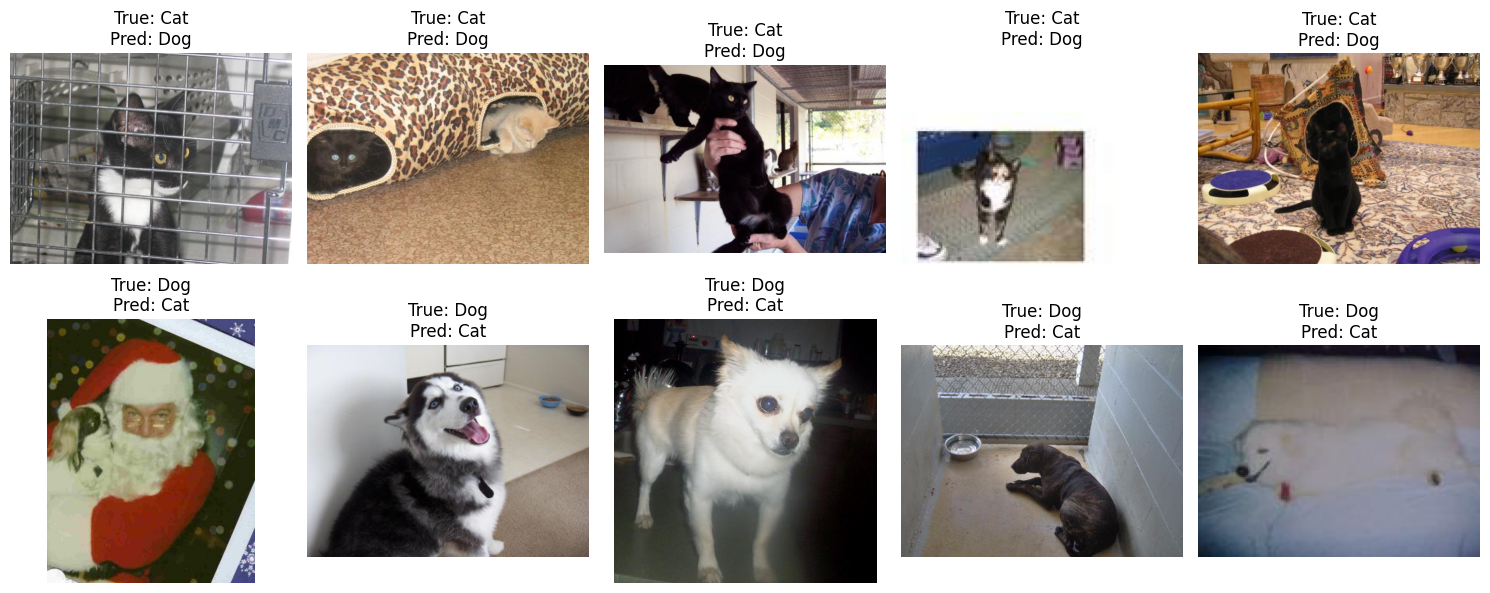

In [92]:
plot_misclassified_grid(all_paths, tl_true_labels, tl_predictions, tl_false_positive_idx, tl_false_negative_idx, class_names)

The "Cat predicted as Dog" errors show varied but recognizable patterns: one cat is photographed inside a wire cage, another inside a leopard-print patterned tunnel bed (an unusual textured background), a third is a black cat being lifted and held by a person (partial occlusion, unusual vertical pose), a fourth is a calico cat viewed full-body from a distance on a tiled outdoor floor, and a fifth is a black cat sitting on a patterned rug near colorful toys - several of these involve atypical poses or textured/patterned surroundings that differ from a plain portrait shot.

The "Dog predicted as Cat" errors include a Christmas-themed photo of a small dog held in Santa Claus's arms (an unusual staged, costumed context rather than a plain photograph), a close-up of a husky with its mouth open mid-pant, a light-colored dog standing indoors in dim lighting, a dog lying down behind kennel or cage bars (mirroring the cage occlusion seen in the cat errors), and a light-colored dog lying on similarly light-colored bedding with very low contrast, making the subject's outline difficult to distinguish even for a human viewer at a glance.

Overall, the model's remaining errors are dominated by occlusion (cage bars, being held by a person), unusual staged or textured contexts (a costumed holiday photo, a patterned tunnel bed), and low-contrast blending with the background, rather than the pose or lighting variations that caused most baseline errors. This suggests that after fine-tuning, the model's failure modes have shifted toward genuinely difficult visual conditions rather than ordinary photographic ambiguity.

#### 10.7.3 Prediction Confidence on Misclassified Images

As with the previous models, we check whether the transfer learning model's rare mistakes are close calls or confident errors, using the raw sigmoid output before thresholding. Note that predictions are computed on the 160x160 images used by this model (`test_dataset_tl`), matching its training resolution.

Mean distance from decision boundary (0.5): 0.3052
Median distance from decision boundary (0.5): 0.3139


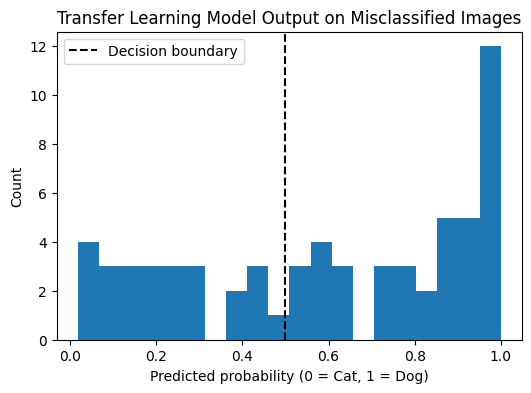

In [93]:
tl_misclassified_confidences = compute_misclassified_confidences(transfer_model, test_dataset_tl, tl_misclassified_indices)
tl_distance_from_boundary = plot_confidence_histogram(tl_misclassified_confidences, title="Transfer Learning Model Output on Misclassified Images")

The mean distance from the decision boundary is 0.3052 (median 0.3139) - higher than both the original baseline (0.1901) and the extended baseline (0.2340). This means that although the transfer learning model makes far fewer mistakes overall, the mistakes it does make tend to be more confidently wrong on average. The histogram shows a prominent spike near 1.0, consistent with the cat-predicted-as-dog cases dominating the error count (40 out of 65) and several of them being confidently misclassified.

This pattern fits the qualitative observations from Section 10.7.2: the remaining errors are largely driven by occlusion, unusual staged contexts, and low-contrast blending, rather than genuinely ambiguous photographs. A highly capable model tends to be confidently wrong on inputs that fall outside typical conditions, rather than uncertain, since it has no strong visual precedent to hedge against - unlike the baseline models, whose errors clustered closer to the decision boundary (0.5), reflecting more genuine visual ambiguity between similar-looking cats and dogs.

## 11. Conclusion and Future Work

This project built a complete, end-to-end image classification pipeline for distinguishing cats from dogs, using the task as a vehicle for demonstrating a broad range of deep learning techniques rather than as an end in itself. Five models were trained and evaluated on the same held-out test set, allowing for a direct comparison of approaches:

| Model | Test Accuracy | Notes |
|---|---|---|
| Baseline CNN (15 epochs) | 79.36% | Trained from scratch; not yet converged |
| Baseline CNN, extended (40 epochs) | 86.42% | Confirmed the 15-epoch model was undertrained |
| Baseline CNN + augmentation (15 epochs) | 74.17% | Underperformed due to insufficient training time |
| Baseline CNN + augmentation, extended (40 epochs) | 81.21% | Fully recovered and slightly exceeded the non-augmented baseline |
| Fine-tuned MobileNetV2 (transfer learning) | 98.15% | Dramatically outperformed all from-scratch models |

Several key findings emerged from this comparison:

- **The baseline model was initially undertrained.** The overfitting check (Section 7.4) showed validation loss was still decreasing at epoch 15, and extending training to 40 epochs (Section 7.5) confirmed this, improving test accuracy by 7.06 percentage points without any architectural changes.
- **Data augmentation is not a free improvement, but it is not harmful either.** With the same fixed 15-epoch budget as the baseline, augmentation initially performed worse (Section 9), not because augmentation itself was harmful, but because the added training variability slowed convergence. Once given the same generous training budget as the extended baseline (Section 9.5), the augmented model not only recovered the gap but slightly exceeded the non-augmented baseline (81.21% vs 79.36%), suggesting augmentation's regularizing effect becomes beneficial once the model is given enough time to converge. Section 9.6 further examined why the specific augmentation configuration used (mild rotation, zoom, and flipping only) still left room for improvement, identifying several concrete limitations - conservative transformation ranges, no color or lighting variation, no occlusion simulation, and limited model capacity to exploit the added diversity.
- **Transfer learning was by far the most effective technique.** Leveraging a MobileNetV2 backbone pretrained on ImageNet reached 98.15% test accuracy - an improvement of 18.79 percentage points over the original 15-epoch baseline, and still 11.73 percentage points ahead of the best-performing from-scratch model (the extended baseline at 86.42%). The overfitting check (Section 10.6) showed mild overfitting emerging after epoch 4, but `restore_best_weights=True` successfully recovered the best-performing weights.
- **Error patterns shifted qualitatively as models improved.** The baseline models' mistakes clustered around genuinely ambiguous photos - unusual poses, close-up crops, and lighting that removed the usual visual cues separating cats and dogs (Sections 8 and 8.4). The transfer learning model's much smaller set of remaining errors (Section 10.7) instead clustered around occlusion (cage or crate bars, being held by a person), unusual staged or textured contexts (a costumed holiday photo, a patterned tunnel bed), and low-contrast blending with the background, rather than ordinary photographic ambiguity - and its errors were, on average, more confidently wrong, consistent with a well-generalizing model encountering genuinely difficult visual conditions rather than everyday ambiguity.

Several directions could extend this work further:

- **Stronger, more varied augmentation**: incorporating brightness/contrast variation, random cropping, or cutout, as identified in Section 9.6, could further improve on the already-strong extended augmented result.
- **Fine-tuning deeper layers**: unfreezing the last few layers of the MobileNetV2 backbone and training them with a very small learning rate could push accuracy even higher than the current frozen-backbone approach.
- **Hyperparameter tuning**: systematically testing different learning rates, batch sizes, and architectures (number of filters, additional convolutional blocks) was identified as a possible direction, though not pursued here given the limited marginal value relative to the transfer learning results already achieved.
- **Handling out-of-distribution inputs**: since the transfer learning model's remaining errors were dominated by occlusion and unusual staged contexts rather than ordinary photographs, explicitly detecting or flagging such inputs (rather than forcing a cat/dog prediction) could be a practical improvement for real-world deployment.

## References

**Dataset:** [Microsoft "Kaggle Cats and Dogs" Dataset](https://www.microsoft.com/en-us/download/details.aspx?id=54765)

**Pretrained model:** MobileNetV2 (Sandler et al., 2018), pretrained on ImageNet, used via `keras.applications.MobileNetV2`.